# Proyecto 1 - Parte 1

## Pedro Pablo Sanín Trujillo - 202221527


## Parte 1 - Importación de librerías y preprocesamiento de los textos.

Primero explicaremos el funcionamiento del procesamiento en un documento individual y luego construiremos el pipeline para aplicar las transformaciones al conjunto de datos. Inicialmente, haremos el preprocesamiento de los textos del conjunto de entrenamiento. Luego, tokenizaremos el texto para dividirlo en palabras individuales. Finalmente, hacemos stemming para que las palabras con la misma raíz sean consideradas como la misma palabra. Note que, en general, no nos interesan las terminaciones de las palabras. Por ejemplo, en el contexto del problema, las palabras: compra, compras y compramos nos transmiten básicamente la misma información. Tomar estas palabras como diferentes hace que los modelos sean innecesariamente pesados y complicados.

- Tokenización: Usaremos `word_tokenize` de `NLTK`.
- Stemming: Usaremos `SnowballStemmer` de `NLTK` con el idioma fijado en `spanish`.


In [43]:
# Importación de librerías
import nltk
import numpy as np
import pandas as pd
from imblearn.pipeline import Pipeline
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV,
    cross_val_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

nltk.download(
    "punkt_tab"
)  # Descargamos el tokenizador de NLTK para poder usar word_tokenize
nltk.download(
    "stopwords"
)  # Descargamos las stopwords de NLTK para poder filtrar palabras comunes

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Administrador\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrador\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [44]:
df = pd.read_csv("data/train.csv")

data = df.copy(deep=True)

print(f"Documentos cargados: {len(data)}")
data.head()

Documentos cargados: 12000


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


In [45]:
data.describe(include=["object"])

,text,label
count,12000,12000
unique,12000,3
top,Lo pedi a medados de mes y me llego en unos cu...,positivo
freq,1,4212


In [46]:
data["label"].value_counts()

label
positivo    4212
negativo    4212
neutral     3576
Name: count, dtype: int64

Vemos que en este caso, no tenemos datos faltantes inválidos, además, el número de datos de cada categoría es mas o menos igual. Por lo que podemos proceder directamente a la tokenización y stemming.


Luego identificamos las `stop words` en español presentes en el texto. Estas son palabras que no agregan significado al texto, como y, de, un, entre otras.

Para procesar estas palabras, usamos `stopwords` de `nltk.corpus` Al final, construimos una función `tokenizer_stemmer` para aplicar la tokenización, stemming y eliminación de stopwords.

Asimismo, revisamos el conjunto de stopwords y eliminamos aquellas que expresen algo negativo, pues estas nos ayudan a clasificar correctamente los mensajes. También conservamos los conectores de contraste ("pero", "sin") y los intensificadores ("muy", "más", "mucho", "nada"), que cambian el sentido de una frase.

Muchas reseñas están escritas sin tildes ("llego", "segun", "asi"), por lo que se quitan las tildes del texto y de las stopwords antes de comparar. Así "llegó" y "llego" son el mismo token.

Por último, marcamos el alcance de la negación: a cada palabra que sigue a un negador ("no", "nunca", "sin", "nada", ...) se le agrega el prefijo `NEG_` hasta el siguiente signo de puntuación o conector adversativo. De esta forma "no me gustó la comida" produce `NEG_gust` y `NEG_com`, que el modelo distingue de `gust` y `com`.


In [47]:
import unicodedata


def quitar_tildes(text):
    """Elimina tildes y diéresis, pues muchas reseñas están escritas sin ellas."""
    return unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")


spanish_stopwords_completas = set(stopwords.words("spanish"))

palabras_negativas = {
    "no",
    "nunca",
    "jamás",
    "nadie",
    "ninguno",
    "poco",
    "ni",
    "pero",
    "sin",
    "muy",
    "más",
    "mucho",
    "nada",
    "contra",
    "algo",
}

# Se comparan sin tildes porque el texto también se normaliza sin tildes
spanish_stopwords = {
    quitar_tildes(w) for w in spanish_stopwords_completas - palabras_negativas
}

# Lista mínima (artículos, preposiciones y pronombres) para no romper frases hechas como "con los ojos cerrados"
stopwords_minimas = {
    quitar_tildes(w)
    for w in [
        "el",
        "la",
        "los",
        "las",
        "un",
        "una",
        "unos",
        "unas",
        "de",
        "del",
        "al",
        "y",
        "o",
        "e",
        "a",
        "en",
        "que",
        "lo",
        "le",
        "les",
        "se",
        "me",
        "mi",
        "mis",
        "su",
        "sus",
    ]
}

print(f"Cantidad de stopwords en español: {len(spanish_stopwords)}")
print(f"Contiene no: {'no' in spanish_stopwords}")
print(spanish_stopwords)

Cantidad de stopwords en español: 295
Contiene no: False
{'sois', 'estabas', 'tendreis', 'esten', 'sereis', 'e', 'nosotros', 'habreis', 'sentid', 'tanto', 'te', 'habrias', 'les', 'ellos', 'en', 'he', 'habre', 'estados', 'hubiese', 'haya', 'tuviste', 'estas', 'por', 'tuvieron', 'hubieras', 'serian', 'tuve', 'otra', 'tuyos', 'otras', 'me', 'mios', 'habriamos', 'vuestras', 'tenian', 'fuisteis', 'estare', 'tuviera', 'estara', 'seamos', 'eres', 'tienen', 'estamos', 'hubiesen', 'esta', 'habidos', 'nos', 'habiais', 'sean', 'nosotras', 'eran', 'estuve', 'sere', 'habran', 'tambien', 'fueramos', 'hube', 'estuvisteis', 'habido', 'fuimos', 'hubieran', 'habida', 'tengan', 'soy', 'este', 'mis', 'nuestra', 'nuestro', 'estuvimos', 'estais', 'fui', 'tenemos', 'todos', 'cuando', 'tendremos', 'ellas', 'uno', 'fuese', 'hubimos', 'hubieron', 'fueses', 'erais', 'el', 'tuvo', 'estabamos', 'hayais', 'habia', 'vosotras', 'seremos', 'tenidos', 'tendran', 'hubieses', 'teniamos', 'yo', 'estes', 'un', 'tengais', '

In [48]:
stemmer = SnowballStemmer("spanish")

# Palabras que niegan lo que viene después de ellas (sin tildes, como el texto normalizado)
NEGADORES = {
    "no",
    "nunca",
    "jamas",
    "ni",
    "nada",
    "sin",
    "tampoco",
    "nadie",
    "ninguno",
    "ninguna",
}
# Tokens que cierran el alcance de una negación: puntuación y conectores adversativos
FIN_NEGACION = {".", ",", ";", ":", "!", "?", "pero", "aunque", "sino"}
NEG_PREFIX = "NEG_"


def marcar_negacion(tokens):
    """Agrega el prefijo NEG_ a las palabras dentro del alcance de una negación, es decir,
    desde el negador hasta el siguiente signo de puntuación o conector adversativo."""
    marcados, negando = [], False
    for t in tokens:
        if t in FIN_NEGACION:
            negando = False
        elif t in NEGADORES:
            negando = True
        elif negando:
            t = NEG_PREFIX + t
        marcados.append(t)
    return marcados


def tokenizer_stemmer(text, stopwords=spanish_stopwords, stemming=True):
    """Hacemos el preprocesamiento del texto: normalización, tokenización, marcado de negación y stemming en una sola función para luego pasarlo al pipeline de procesamiento."""
    tokens = marcar_negacion(word_tokenize(quitar_tildes(text.lower())))
    resultado = []
    for t in tokens:
        palabra = t.removeprefix(NEG_PREFIX)
        if palabra.isalpha() and palabra not in stopwords:
            prefijo = NEG_PREFIX if t.startswith(NEG_PREFIX) else ""
            resultado.append(prefijo + (stemmer.stem(palabra) if stemming else palabra))
    return resultado

In [49]:
ejemplo = "No me gustó para nada la batería, pero la pantalla es excelente."
tokenizer_stemmer(ejemplo)

['no', 'NEG_gust', 'nad', 'NEG_bateri', 'per', 'pantall', 'excelent']

### Análisis de las oraciones

In [50]:
import re

# Vocabulario del generador de reseñas: aspectos del producto y frases de opinión fijas
ASPECTOS = [
    "duracion de la bateria", "atencion al cliente", "resistencia al agua", "nitidez de la imagen", "manual de uso",
    "boton de encendido", "sistema de sonido", "sistema de carga", "app del fabricante", "menu de ajustes",
    "relacion calidad-precio", "relacion calidad precio", "calidad de sonido", "calidad de imagen", "cable de carga",
    "calidad de construccion", "calidad del sonido", "pantalla", "empaque", "precio", "cargador", "instalacion",
    "tamano", "control", "acabado", "bateria", "construccion", "correa", "autonomia", "procesador", "resolucion",
    "peso", "portabilidad", "camara", "senal", "ensamblaje", "velocidad", "ventilador", "sonido", "aplicacion",
    "motor", "material", "microfono", "conexion", "rendimiento", "teclado", "soporte", "carcasa", "funda",
    "terminacion", "tapa", "memoria", "comodidad", "ergonomia", "cable", "interfaz", "diseno", "color", "calidad",
]
PATRON_ASPECTO = re.compile(r"\b(" + "|".join(sorted(map(re.escape, ASPECTOS), key=len, reverse=True)) + r")\b")

FRASES_NEGATIVAS = [
    "no vale lo que cuesta", "me decepciono", "por debajo de la media", "se queda muy corto", "se queda corto",
    "se dano antes", "no es para nada lo que esperaba", "defraudo todas mis expectativas", "tire el dinero",
    "funciona bastante mal", "dolor de cabeza", "me arrepiento", "no le recomiendo", "error de compra",
    "quede muy molesto", "no volveria a comprar", "una estrella", "no pare de tener problemas", "arrepentido",
    "termine harto",
]
FRASES_POSITIVAS = [
    "justo lo que estaba buscando", "vale totalmente la pena", "fue todo un acierto", "me encanto",
    "funciona de maravilla", "respondio tal como esperaba", "supero todas mis expectativas", "cumple de sobra",
    "por encima de la media", "me alegra haber elegido", "me sorprendio para bien", "me hizo la vida mas facil",
    "termine feliz", "estoy feliz", "quede encantado", "con los ojos cerrados", "volveria a comprar",
    "ni una sola queja", "cinco estrellas",
]


# Adjetivos de la plantilla "<aspecto> es/resultó/me salió <adjetivo>"
ADJETIVOS_POSITIVOS = [
    "funcional", "resistente", "impecable", "sobresaliente", "veloz", "confiable", "excelente", "eficiente",
    "formidable", "fiable", "potente", "superior", "decente", "notable", "espectacular", "durable", "practica",
    "practico", "cumplidor", "cumplidora", "agradable", "comodisima", "comodisimo", "buenisima", "buenisimo",
    "rapidisima", "rapidisimo", "comoda", "comodo", "optimo", "optima", "correcta", "correcto", "solida", "solido",
    "redonda", "redondo", "ligera", "ligero", "completa", "completo", "robusta", "robusto", "buena", "bueno",
    "nitida", "nitido", "precisa", "preciso", "estupenda", "estupendo", "bien hecha", "bien hecho", "bien logrado",
    "bien lograda", "bien construida", "bien construido",
]
ADJETIVOS_NEGATIVOS = [
    "torpe", "pobre", "terrible", "decepcionante", "endeble", "debil", "desagradable", "fragil", "corriente",
    "inestable", "deficiente", "mediocre", "inconsistente", "olvidable", "incumplidor", "incumplidora", "ruidosa",
    "ruidoso", "imprecisa", "impreciso", "delicada", "delicado", "lentisima", "lentisimo", "pesima", "pesimo",
    "malisima", "malisimo", "flojo", "floja", "ordinaria", "ordinario", "aparatoso", "aparatosa", "chapucera",
    "chapucero", "basica", "basico", "incomoda", "incomodo", "limitado", "limitada", "defectuosa", "defectuoso",
    "mal terminada", "mal terminado", "mal construida", "mal construido", "mal hecha", "mal hecho",
]
PATRON_ADJ_POSITIVO = re.compile(r"\b(?:" + "|".join(ADJETIVOS_POSITIVOS) + r")\b")
PATRON_ADJ_NEGATIVO = re.compile(r"\b(?:" + "|".join(ADJETIVOS_NEGATIVOS) + r")\b")


def polaridad_clausula(clausula):
    """+1, -1 o 0. Primero busca las frases fijas (las negativas antes, por "no volveria a comprar")
    y si no hay ninguna, compara cuántos adjetivos positivos y negativos tiene."""
    if any(f in clausula for f in FRASES_NEGATIVAS):
        return -1
    if any(f in clausula for f in FRASES_POSITIVAS):
        return 1
    puntaje = len(PATRON_ADJ_POSITIVO.findall(clausula)) - len(PATRON_ADJ_NEGATIVO.findall(clausula))
    return int(np.sign(puntaje))

CONECTORES = sorted(
    ["sin embargo", "eso si", "aun asi", "lo que si", "no obstante", "a fin de cuentas", "al final", "con todo",
     "por otro lado", "por cierto", "de paso", "ademas", "ahora", "pero", "aunque", "y", "la verdad"],
    key=len, reverse=True,
)
SEPARADOR_CLAUSULAS = re.compile(
    r"([.;!?]|,?\s\b(?:pero|aunque|sin embargo|eso si|aun asi|lo que si|no obstante|y)\b)"
)


def extraer_opiniones(texto):
    """Lista de (aspecto, polaridad, conector) de cada cláusula que menciona un aspecto con una opinión.
    El conector es el que aparece justo antes o al inicio de la cláusula ("" si no hay)."""
    partes = SEPARADOR_CLAUSULAS.split(quitar_tildes(texto.lower()))
    opiniones, separador = [], ""
    for i in range(0, len(partes), 2):
        clausula = partes[i].strip(" ,")
        aspectos = PATRON_ASPECTO.findall(clausula)
        polaridad = polaridad_clausula(clausula) if aspectos else 0
        if polaridad:
            contexto = separador + " " + clausula[:30]
            conector = next((c for c in CONECTORES if re.search(rf"\b{c}\b", contexto)), "")
            opiniones.append((aspectos[0], polaridad, conector))
        separador = partes[i + 1] if i + 1 < len(partes) else ""
    return opiniones


extraer_opiniones(
    "Me decepcionó el ensamblaje de principio a fin. Al final, la tapa cumple de sobra."
)

[('ensamblaje', -1, ''), ('tapa', 1, 'al final')]

In [51]:
no_neutros = data[data["label"] != "neutral"]
opiniones = no_neutros["text"].apply(extraer_opiniones)

# Reseñas mixtas: exactamente una opinión positiva y una negativa
mixtas = opiniones.apply(lambda o: sorted(p for _, p, _ in o) == [-1, 1])
etiqueta = no_neutros.loc[mixtas, "label"].map({"positivo": 1, "negativo": -1})
analisis_conectores = pd.DataFrame(
    {
        "conector_ultima": opiniones[mixtas].apply(lambda o: o[-1][2] or "(ninguno)"),
        "gana_ultima": opiniones[mixtas].apply(lambda o: o[-1][1]) == etiqueta,
    }
)

print(f"Reseñas no neutrales con al menos una opinión detectada: {(opiniones.str.len() > 0).mean():.1%}")
print(f"Reseñas mixtas: {mixtas.sum()} ({mixtas.mean():.0%} de las no neutrales)")
print(f"La última opinión coincide con la etiqueta en el {analisis_conectores['gana_ultima'].mean():.1%} de las mixtas")

analisis_conectores.groupby("conector_ultima")["gana_ultima"].agg(
    resenas="size", coincide_etiqueta="mean"
).sort_values("resenas", ascending=False).round(2)

Reseñas no neutrales con al menos una opinión detectada: 96.3%
Reseñas mixtas: 5066 (60% de las no neutrales)
La última opinión coincide con la etiqueta en el 84.5% de las mixtas


,resenas,coincide_etiqueta
conector_ultima,,
eso si,1007,0.83
(ninguno),757,0.82
al final,654,1.00
aun asi,550,0.99
por otro lado,325,0.52
con todo,315,1.00
pero,232,0.99
y,226,0.83
a fin de cuentas,205,1.00


## Parte 2 - Construcción del pipeline de preprocesamiento

A continuación, debemos construir una representación de nuestro texto que sea matemáticamente comprensible para nuestros modelos. Para hacer eso, usamos una representación en matrices dispersas. Para este propósito `sk-learn` ofrece varias formas de convertir nuestro texto en matrices dispersas.

- CountVectorizer: Produce una matriz dispersa


In [52]:
import re
from collections import Counter, defaultdict
from functools import partial

TEXT_COLUMN = "text"
COLUMN_LAST_SENTENCE = "last_sentence"
COLUMN_CONTRAST = "after_contrast"
TARGET_COLUMN = "label"

VECTORIZERS = {
    "count": CountVectorizer,
    "tfidf": TfidfVectorizer,
}


def extract_last_sentences(text, n_sentences):
    """Extrae las últimas n_sentences oraciones no vacías de un texto."""
    sentences = [s.strip() for s in text.split(".") if s.strip()]
    return ". ".join(sentences[-n_sentences:]) if sentences else ""


def add_last_sentences(X, n_sentences=1):
    """Agrega la columna con la última oración del texto, conservando las columnas originales."""
    return X.assign(
        **{
            COLUMN_LAST_SENTENCE: X[TEXT_COLUMN].apply(
                lambda x: extract_last_sentences(x, n_sentences)
            )
        }
    )


# Conectores tras los cuales suele estar la opinión que define la reseña: "La pantalla es mala. Eso sí, la batería es excelente".
# "por otro lado", "en cambio" y "en general" no se incluyen porque la cláusula que sigue no predice mejor la etiqueta que la anterior.
CONECTORES_CONTRASTE = [
    "pero",
    "sin embargo",
    "aunque",
    "no obstante",
    "aun asi",
    "con todo",
    "lo que si",
    "a fin de cuentas",
    "al final"
]
PATRON_CONTRASTE = re.compile(r"\b(?:" + "|".join(CONECTORES_CONTRASTE) + r")\b")


def extract_after_contrast(text):
    """Extrae la oración que sigue al último conector de contraste, o una cadena vacía si no hay ninguno."""
    normalizado = quitar_tildes(text.lower())
    coincidencias = list(PATRON_CONTRASTE.finditer(normalizado))
    if not coincidencias:
        return ""
    return normalizado[coincidencias[-1].end() :].split(".")[0].strip(" ,")


def add_after_contrast(X):
    """Agrega la columna con la oración posterior al último conector de contraste, conservando las columnas originales."""
    return X.assign(**{COLUMN_CONTRAST: X[TEXT_COLUMN].apply(extract_after_contrast)})


def remove_first_sentence(X):
    """Elimina la primera oración del texto, conservando las columnas originales."""

    def first_sentence_removed(text):
        sentences = [s.strip() for s in text.split(".") if s.strip()]
        return ". ".join(sentences[1:]) if len(sentences) > 1 else ""

    return X.assign(**{TEXT_COLUMN: X[TEXT_COLUMN].apply(first_sentence_removed)})


def split_sentences(text):
    """Divide el texto en oraciones no vacías."""
    return [s.strip() for s in text.split(".") if s.strip()]


def normalize_sentence(sentence):
    """Normaliza una oración para compararla con otras: minúsculas, sin tildes y sin comas en los extremos."""
    return quitar_tildes(sentence.lower()).strip(" ,")




def vectorizer_function(
    vectorizer="count",
    ngram_range=(1, 3),
    stopwords=spanish_stopwords,
    stemming=True,
    sublinear_tf=False,
    min_df=1,
):
    """Vectorizador de palabras con el tokenizador propio. sublinear_tf (1 + log(tf)) solo existe en TF-IDF,
    por eso se pasa únicamente a TfidfVectorizer."""
    tfidf_kwargs = {"sublinear_tf": sublinear_tf} if vectorizer == "tfidf" else {}
    return VECTORIZERS[vectorizer](
        tokenizer=partial(tokenizer_stemmer, stopwords=stopwords, stemming=stemming),
        token_pattern=None,
        ngram_range=ngram_range,
        min_df=min_df,
        **tfidf_kwargs,
    )




def build_preprocessor(
    vectorizer="count",
    ngram_range=(1, 3),
    stopwords=spanish_stopwords,
    stemming=True,
    sublinear_tf=False,
    min_df=1,
):
    """Construye el preprocesador de las features con el vectorizador indicado: 'count' o 'tfidf'.

    1. Crea la columna con la última oración y la columna con la oración posterior al último conector de contraste.
    2. Opcionalmente elimina la primera oración del texto completo (por defecto no la elimina;
       en el grid search se prueba con FunctionTransfomer(remove_first_sentence)).
    3. Vectoriza por separado el texto completo, la última oración y la oración posterior al contraste.
       ngram_range, stopwords, sublinear_tf y min_df controlan los tres vectorizadores de palabras.
    """
    word_vectorizer = partial(
        vectorizer_function, vectorizer, ngram_range, stopwords, stemming, sublinear_tf, min_df
    )
    vectorizers = [
        ("text_vectorizer", word_vectorizer(), TEXT_COLUMN,),
        ("last_sentence_vectorizer", word_vectorizer(), COLUMN_LAST_SENTENCE),
        ("contrast_vectorizer", word_vectorizer(), COLUMN_CONTRAST),
    ]
    steps = []
    return Pipeline(
        steps
        + [
            (
                "last_sentence",
                FunctionTransformer(add_last_sentences, kw_args={"n_sentences": 1}),
            ),
            ("after_contrast", FunctionTransformer(add_after_contrast)),
            ("remove_first_sentence", FunctionTransformer(remove_first_sentence)),
            ("vectorizers", ColumnTransformer(vectorizers)),
        ]
    )

In [53]:
preprocessor = build_preprocessor("tfidf")
preprocessor

,steps,"[('last_sentence', ...), ('after_contrast', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...0023D7F90D800>
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",{'n_sentences': 1}
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None


In [54]:
X = data.drop(TARGET_COLUMN, axis=1)
y = data[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ambos se ajustan solo con train
preprocessor = build_preprocessor("tfidf")
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)


print(f"X - Train: {X_train_transformed.shape} | Test: {X_test_transformed.shape}")


X - Train: (9600, 199644) | Test: (2400, 199644)


In [55]:
vectorizers = preprocessor.named_steps["vectorizers"].named_transformers_

for name in ["text_vectorizer", "last_sentence_vectorizer", "contrast_vectorizer"]:
    print(f"Vocabulary size ({name}): {len(vectorizers[name].vocabulary_)}")

vocabulary = pd.DataFrame(
    vectorizers["text_vectorizer"].vocabulary_.items(), columns=["term", "index"]
)
vocabulary

Vocabulary size (text_vectorizer): 141524
Vocabulary size (last_sentence_vectorizer): 45426
Vocabulary size (contrast_vectorizer): 12694


,term,index
0,lleg,76732
1,uso,132851
2,gimnasi,66906
3,carg,31454
4,hac,68713
...,...,...
141519,agarr grand pas,17443
141520,grand pas boton,67522
141521,encend mantuv liger,57054
141522,mantuv liger dia,80692


## Entrenamiento del modelo inicial de regresión logística


Accuracy Logistic Regression: 0.8908333333333334
              precision    recall  f1-score   support

    negativo       0.85      0.86      0.86       843
     neutral       0.97      0.99      0.98       715
    positivo       0.86      0.83      0.85       842

    accuracy                           0.89      2400
   macro avg       0.89      0.90      0.89      2400
weighted avg       0.89      0.89      0.89      2400



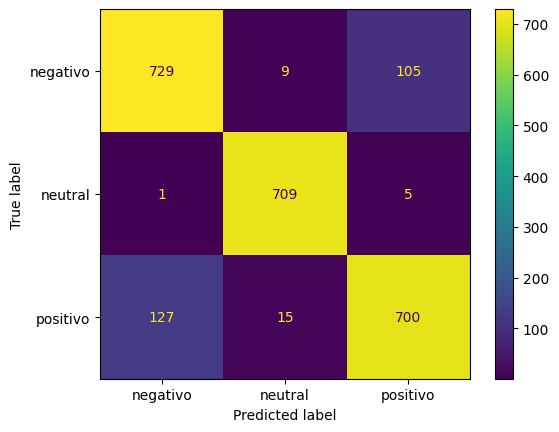

In [56]:
logistic_regression_classifier = LogisticRegression(max_iter=1000)
logistic_regression_classifier.fit(X_train_transformed, y_train)

y_pred_logistic_regression = logistic_regression_classifier.predict(X_test_transformed)

accuracy_logistic_regression = accuracy_score(y_test, y_pred_logistic_regression)
print(f"Accuracy Logistic Regression: {accuracy_logistic_regression}")
print(classification_report(y_test, y_pred_logistic_regression))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logistic_regression)
plt.show()

## Árbol de decision


Accuracy Decision Tree: 0.61125
              precision    recall  f1-score   support

    negativo       0.49      0.83      0.62       843
     neutral       0.85      0.83      0.84       715
    positivo       0.66      0.21      0.31       842

    accuracy                           0.61      2400
   macro avg       0.66      0.62      0.59      2400
weighted avg       0.65      0.61      0.58      2400



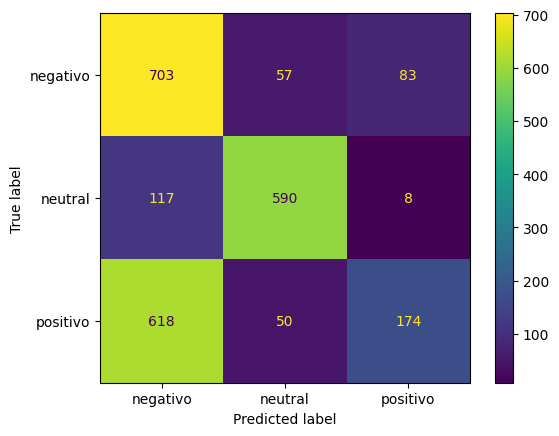

In [57]:
# Entrenamiento y evaluación del modelo Decision Tree con profundidad máxima de 10
decision_tree_classifier = DecisionTreeClassifier(max_depth=10)
decision_tree_classifier.fit(X_train_transformed, y_train)
y_pred_dt = decision_tree_classifier.predict(X_test_transformed)

accuracy_decision_tree = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy Decision Tree: {accuracy_decision_tree}")
print(classification_report(y_test, y_pred_dt))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.show()

## AdaBoost


In [58]:
# ada_classifier = AdaBoostClassifier(
#     estimator=DecisionTreeClassifier(max_depth=3), n_estimators=1000, learning_rate=1.0
# )
# ada_classifier.fit(X_train_transformed, y_train)
# y_pred_ab = ada_classifier.predict(X_test_transformed)

# accuracy_adaboost = accuracy_score(y_test, y_pred_ab)
# print(f"Accuracy AdaBoost: {accuracy_adaboost}")
# print(classification_report(y_test, y_pred_ab))
# ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ab)
# plt.show()

## Random Forest


Accuracy Random Forest: 0.7754166666666666
              precision    recall  f1-score   support

    negativo       0.71      0.71      0.71       843
     neutral       0.87      0.99      0.93       715
    positivo       0.74      0.66      0.70       842

    accuracy                           0.78      2400
   macro avg       0.78      0.79      0.78      2400
weighted avg       0.77      0.78      0.77      2400



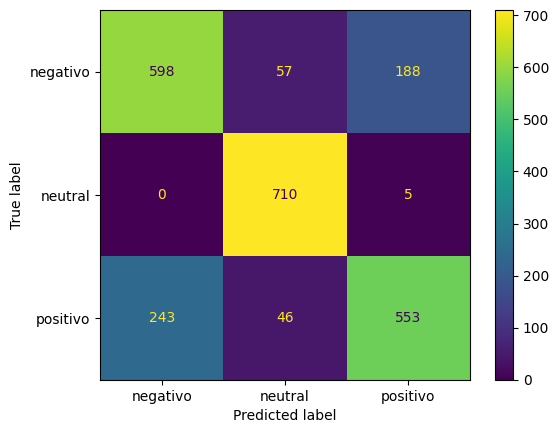

In [59]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train_transformed, y_train)
y_pred = random_forest.predict(X_test_transformed)
accuracy_random_forest = accuracy_score(y_test, y_pred)
print(f"Accuracy Random Forest: {accuracy_random_forest}")
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# SVC


c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Accuracy Support Vector Classifier: 0.9
              precision    recall  f1-score   support

    negativo       0.85      0.89      0.87       843
     neutral       0.98      0.99      0.99       715
    positivo       0.89      0.83      0.86       842

    accuracy                           0.90      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.90      0.90      0.90      2400



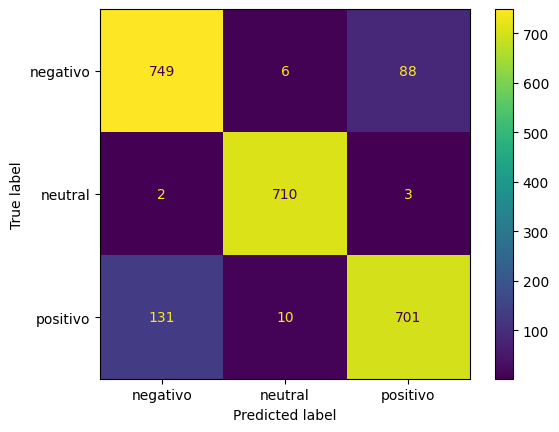

In [60]:
support_vector_classifier = SVC(kernel="sigmoid", C=1.0, probability=True)

support_vector_classifier.fit(X_train_transformed, y_train)
y_pred_svc = support_vector_classifier.predict(X_test_transformed)

accuracy_svc = accuracy_score(y_test, y_pred_svc)
print(f"Accuracy Support Vector Classifier: {accuracy_svc}")
print(classification_report(y_test, y_pred_svc))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc)
plt.show()

## Linear SVC


Accuracy Linear Support Vector Classifier: 0.8904166666666666
              precision    recall  f1-score   support

    negativo       0.85      0.86      0.86       843
     neutral       0.97      0.99      0.98       715
    positivo       0.86      0.84      0.85       842

    accuracy                           0.89      2400
   macro avg       0.89      0.90      0.89      2400
weighted avg       0.89      0.89      0.89      2400



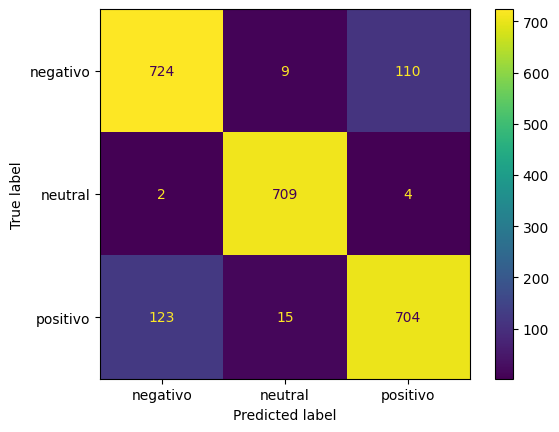

In [61]:
linear_svc = LinearSVC(C=1.0)
linear_svc.fit(X_train_transformed, y_train)
y_pred_linear_svc = linear_svc.predict(X_test_transformed)
accuracy_linear_svc = accuracy_score(y_test, y_pred_linear_svc)
print(f"Accuracy Linear Support Vector Classifier: {accuracy_linear_svc}")
print(classification_report(y_test, y_pred_linear_svc))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_linear_svc)
plt.show()

## Naive Bayes


Accuracy Naive Bayes: 0.8841666666666667
              precision    recall  f1-score   support

    negativo       0.84      0.86      0.85       843
     neutral       0.97      0.99      0.98       715
    positivo       0.86      0.82      0.84       842

    accuracy                           0.88      2400
   macro avg       0.89      0.89      0.89      2400
weighted avg       0.88      0.88      0.88      2400



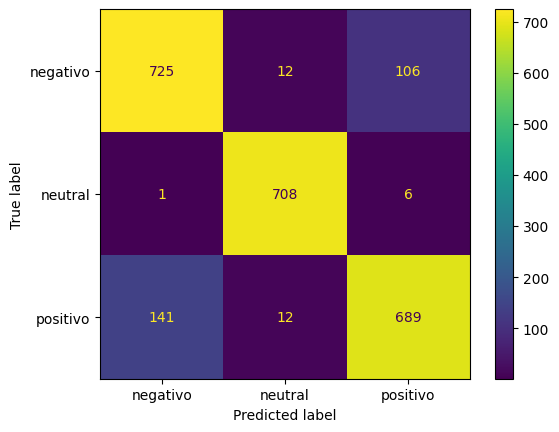

In [62]:
from sklearn.naive_bayes import MultinomialNB

naive_bayes = MultinomialNB()
naive_bayes.fit(X_train_transformed, y_train)
y_pred_naive_bayes = naive_bayes.predict(X_test_transformed)
accuracy_naive_bayes = accuracy_score(y_test, y_pred_naive_bayes)
print(f"Accuracy Naive Bayes: {accuracy_naive_bayes}")
print(classification_report(y_test, y_pred_naive_bayes))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_naive_bayes)
plt.show()

## Complement Naive Bayes

Accuracy Complement Naive Bayes: 0.8745833333333334
              precision    recall  f1-score   support

    negativo       0.84      0.84      0.84       843
     neutral       0.91      1.00      0.95       715
    positivo       0.88      0.80      0.84       842

    accuracy                           0.87      2400
   macro avg       0.88      0.88      0.88      2400
weighted avg       0.87      0.87      0.87      2400



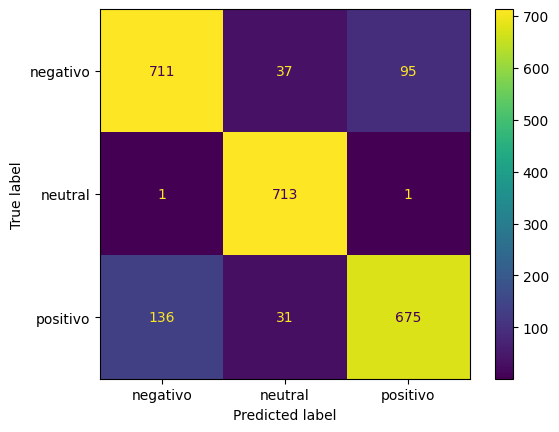

In [63]:
from sklearn.naive_bayes import ComplementNB

comp_naive_bayes = ComplementNB()
comp_naive_bayes.fit(X_train_transformed, y_train)
y_pred_comp_naive_bayes = comp_naive_bayes.predict(X_test_transformed)
accuracy_comp_naive_bayes = accuracy_score(y_test, y_pred_comp_naive_bayes)
print(f"Accuracy Complement Naive Bayes: {accuracy_comp_naive_bayes}")
print(classification_report(y_test, y_pred_comp_naive_bayes))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_comp_naive_bayes)
plt.show()

## Gaussian NB


Accuracy Gaussian Naive Bayes: 0.8179166666666666
              precision    recall  f1-score   support

    negativo       0.75      0.77      0.76       843
     neutral       0.97      0.95      0.96       715
    positivo       0.76      0.75      0.76       842

    accuracy                           0.82      2400
   macro avg       0.83      0.82      0.83      2400
weighted avg       0.82      0.82      0.82      2400



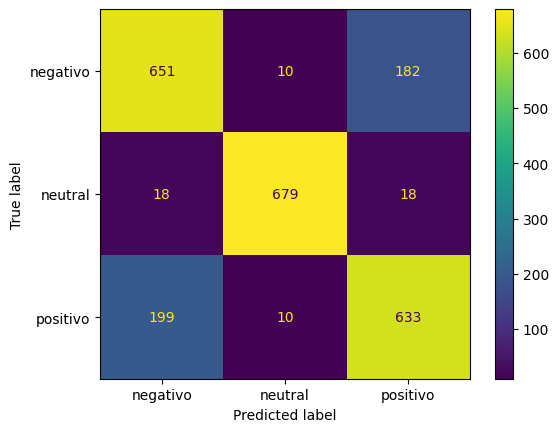

In [64]:

from sklearn.naive_bayes import GaussianNB


gaussian_naive_bayes = GaussianNB(var_smoothing=1e-19)
gaussian_naive_bayes.fit(X_train_transformed.toarray(), y_train)
y_pred_gaussian_naive_bayes = gaussian_naive_bayes.predict(X_test_transformed.toarray())
accuracy_gaussian_naive_bayes = accuracy_score(y_test, y_pred_gaussian_naive_bayes)
print(f"Accuracy Gaussian Naive Bayes: {accuracy_gaussian_naive_bayes}")
print(classification_report(y_test, y_pred_gaussian_naive_bayes))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gaussian_naive_bayes)
plt.show()

## Viendo como clasificar positivo y negativo.

Primero, encontraremos algunas muestras mal clasificadas en el mejor modelo hasta ahora (SVC) y veremos su estructura.


In [65]:
mal_clasificados = pd.DataFrame(columns=["text", "label"])
errores = y_pred_linear_svc != y_test
mal_clasificados["text"] = X_test.loc[errores, TEXT_COLUMN]
mal_clasificados["label"] = y_test[errores]
mal_clasificados["predicted_label"] = y_pred_linear_svc[errores]

mal_clasificados

,text,label,predicted_label
1561,Lo compré hace como tres semanas porque lo vi ...,positivo,neutral
7244,Lo pedí a mediados de mes y llegó en cuatro dí...,positivo,negativo
990,Lo compré para reemplazar otro que ya tenía en...,negativo,positivo
4648,"Me llegó el parlante el martes pasado, lo comp...",positivo,negativo
8896,Lo pedí a mediados de mes y me llegó en unos c...,negativo,positivo
...,...,...,...
3027,Lo compre hace un par de meses para el taller ...,positivo,negativo
7773,Lo compré hace unos días por internet y llegó ...,positivo,negativo
4706,Lo compré a inicios de año y llegó en tres día...,positivo,negativo
11622,Lo pedí a mediados de mes y llegó en cuatro dí...,negativo,positivo


En las entradas mal clasificadas, identifiqué que en general, el origen de la mala clasificación está en que las reseñas son ambiguas o cambian de significado. Creemos un modelo que solamente distinga entre positivo y negativo.


In [66]:
X_train_no_neutros = X_train[y_train != "neutral"]
y_train_no_neutros = y_train[y_train != "neutral"]

X_test_no_neutros = X_test[y_test != "neutral"]
y_test_no_neutros = y_test[y_test != "neutral"]

# Se ajusta solo con train y se reutiliza en test para mantener el mismo vocabulario
preprocessor_no_neutros = build_preprocessor("tfidf")
X_train_no_neutros_transformed = preprocessor_no_neutros.fit_transform(
    X_train_no_neutros
)
X_test_no_neutros_transformed = preprocessor_no_neutros.transform(X_test_no_neutros)

Accuracy without neutral class: 0.8652818991097923
              precision    recall  f1-score   support

    negativo       0.85      0.89      0.87       843
    positivo       0.89      0.84      0.86       842

    accuracy                           0.87      1685
   macro avg       0.87      0.87      0.87      1685
weighted avg       0.87      0.87      0.87      1685



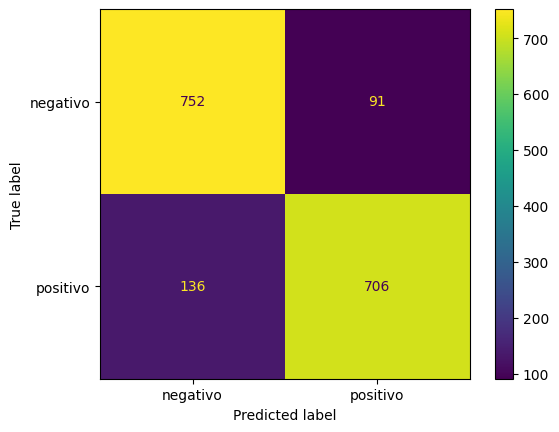

In [67]:
svc_no_neutros = SVC(kernel="sigmoid", C=1.0, gamma=1)
svc_no_neutros.fit(X_train_no_neutros_transformed, y_train_no_neutros)
y_pred_no_neutros = svc_no_neutros.predict(X_test_no_neutros_transformed)
accuracy_no_neutros = accuracy_score(y_test_no_neutros, y_pred_no_neutros)
print("Accuracy without neutral class:", accuracy_no_neutros)

print(classification_report(y_test_no_neutros, y_pred_no_neutros))
ConfusionMatrixDisplay.from_predictions(y_test_no_neutros, y_pred_no_neutros)
plt.show()

Accuracy without neutral class (Decision Tree): 0.7964391691394659
              precision    recall  f1-score   support

    negativo       0.78      0.83      0.80       843
    positivo       0.82      0.76      0.79       842

    accuracy                           0.80      1685
   macro avg       0.80      0.80      0.80      1685
weighted avg       0.80      0.80      0.80      1685



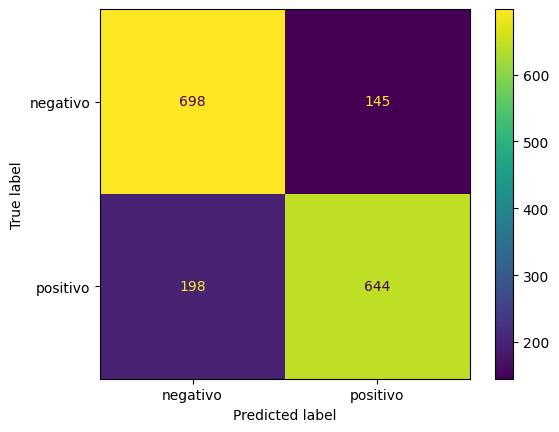

In [68]:
decision_tree_no_neutros = DecisionTreeClassifier()
decision_tree_no_neutros.fit(X_train_no_neutros_transformed, y_train_no_neutros)
y_pred_no_neutros_dt = decision_tree_no_neutros.predict(X_test_no_neutros_transformed)
accuracy_no_neutros_dt = accuracy_score(y_test_no_neutros, y_pred_no_neutros_dt)
print("Accuracy without neutral class (Decision Tree):", accuracy_no_neutros_dt)

print(classification_report(y_test_no_neutros, y_pred_no_neutros_dt))
ConfusionMatrixDisplay.from_predictions(y_test_no_neutros, y_pred_no_neutros_dt)
plt.show()

Accuracy without neutral class (AdaBoost): 0.8077151335311573
              precision    recall  f1-score   support

    negativo       0.89      0.70      0.79       843
    positivo       0.75      0.91      0.83       842

    accuracy                           0.81      1685
   macro avg       0.82      0.81      0.81      1685
weighted avg       0.82      0.81      0.81      1685



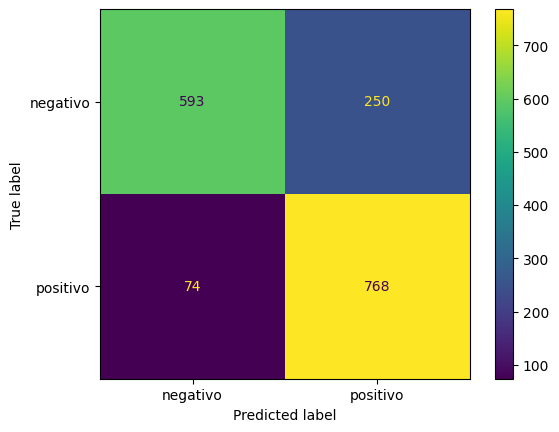

In [69]:
decision_tree_no_neutros = AdaBoostClassifier(n_estimators=1000, learning_rate=1)
decision_tree_no_neutros.fit(X_train_no_neutros_transformed, y_train_no_neutros)
y_pred_no_neutros_dt = decision_tree_no_neutros.predict(X_test_no_neutros_transformed)
accuracy_no_neutros_dt = accuracy_score(y_test_no_neutros, y_pred_no_neutros_dt)
print("Accuracy without neutral class (AdaBoost):", accuracy_no_neutros_dt)

print(classification_report(y_test_no_neutros, y_pred_no_neutros_dt))
ConfusionMatrixDisplay.from_predictions(y_test_no_neutros, y_pred_no_neutros_dt)
plt.show()

Accuracy without neutral class (Random Forest): 0.8267062314540059
              precision    recall  f1-score   support

    negativo       0.81      0.85      0.83       843
    positivo       0.84      0.81      0.82       842

    accuracy                           0.83      1685
   macro avg       0.83      0.83      0.83      1685
weighted avg       0.83      0.83      0.83      1685



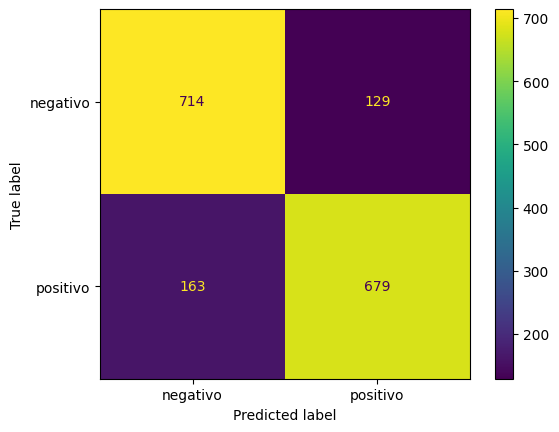

In [70]:
random_forest_no_neutros = RandomForestClassifier(
    n_estimators=1000, max_depth=3, random_state=42
)
random_forest_no_neutros.fit(X_train_no_neutros_transformed, y_train_no_neutros)
y_pred_no_neutros_rf = random_forest_no_neutros.predict(X_test_no_neutros_transformed)
accuracy_no_neutros_rf = accuracy_score(y_test_no_neutros, y_pred_no_neutros_rf)
print("Accuracy without neutral class (Random Forest):", accuracy_no_neutros_rf)

print(classification_report(y_test_no_neutros, y_pred_no_neutros_rf))
ConfusionMatrixDisplay.from_predictions(y_test_no_neutros, y_pred_no_neutros_rf)
plt.show()

Accuracy without neutral class (KNN): 0.7620178041543026
              precision    recall  f1-score   support

    negativo       0.76      0.76      0.76       843
    positivo       0.76      0.77      0.76       842

    accuracy                           0.76      1685
   macro avg       0.76      0.76      0.76      1685
weighted avg       0.76      0.76      0.76      1685



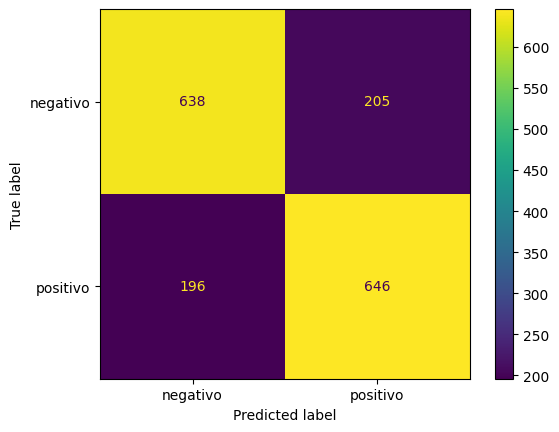

In [71]:
knn_no_neutros = KNeighborsClassifier(n_neighbors=5, metric="cosine")
knn_no_neutros.fit(X_train_no_neutros_transformed, y_train_no_neutros)
y_pred_no_neutros_knn = knn_no_neutros.predict(X_test_no_neutros_transformed)
accuracy_no_neutros_knn = accuracy_score(y_test_no_neutros, y_pred_no_neutros_knn)
print("Accuracy without neutral class (KNN):", accuracy_no_neutros_knn)

print(classification_report(y_test_no_neutros, y_pred_no_neutros_knn))
ConfusionMatrixDisplay.from_predictions(y_test_no_neutros, y_pred_no_neutros_knn)
plt.show()

Creación de un clasificador ensemble. En este caso, nuestros dos mejores modelos fueron SVC y NB, por lo que crearemos un ensemble de votación para elegir la clase basado en ambos modelos. 

In [72]:
# Create a list of labels for the classifiers
from sklearn import model_selection


labels = ['SVC', 'NB']

# Loop through the classifiers and perform 5-fold cross-validation for each
for clf, label in zip([support_vector_classifier, naive_bayes], labels):

    # Use cross_val_score to compute accuracy scores using 5-fold cross-validation
    scores = model_selection.cross_val_score(clf, X_train_transformed, y_train, 
                                              cv=5, 
                                              scoring='accuracy')
    
    # Print the mean accuracy and standard deviation of accuracy for the current classifier
    print("Accuracy: %0.2f (+/- %0.2f) [%s]"
          % (scores.mean(), scores.std(), label))

c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrador\AppData\Local\Programs\Python\Python31

Accuracy: 0.89 (+/- 0.01) [SVC]
Accuracy: 0.87 (+/- 0.01) [NB]


c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Accuracy Voting Classifier: 0.8991666666666667
              precision    recall  f1-score   support

    negativo       0.85      0.89      0.87       843
     neutral       0.98      0.99      0.99       715
    positivo       0.88      0.83      0.86       842

    accuracy                           0.90      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.90      0.90      0.90      2400



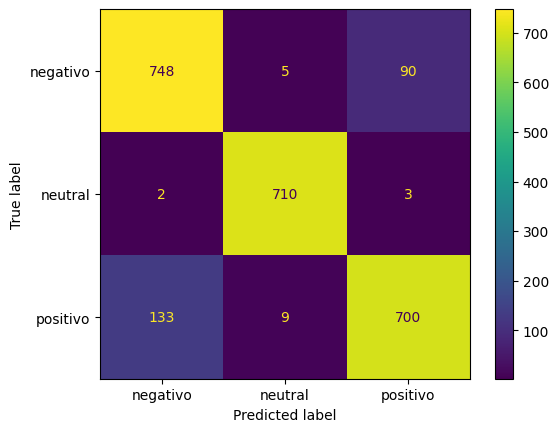

In [73]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.naive_bayes import ComplementNB


# El voto 'soft' requiere predict_proba, por lo que se crea un SVC nuevo con probability=True
voting_classifier = VotingClassifier(
    estimators=[
        ('svc_sigmoid', SVC(kernel="sigmoid", C=1.0, probability=True)),
        ('svc_linear', SVC(kernel="linear", C=1.0, probability=True)),
        ('nb', naive_bayes),

    ],
    voting='soft'
)
voting_classifier.fit(X_train_transformed, y_train)
y_pred_voting = voting_classifier.predict(X_test_transformed)
accuracy_voting = accuracy_score(y_test, y_pred_voting)
print(f"Accuracy Voting Classifier: {accuracy_voting}")
print(classification_report(y_test, y_pred_voting))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_voting)
plt.show()

Este es nuestro mejor modelo. Por ende, ahora vamos a encontrar los mejores hiperparámetros para optimizar el resultado final. 

In [74]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [75]:
param_grid_svc = {
    "kernel": ["sigmoid", "linear", "poly"],
    "gamma": ["scale", "auto"],
    "C": np.linspace(0.1, 1.5, 10),
    "probability": [True]
}

param_grid_lin_svc = {
    "C": np.linspace(0.1, 1.5, 10),
    "gamma": ["scale", "auto"]
}

param_grid_naive_bayes = {
   "alpha": np.logspace(0,-9, num=100),
   "fit_prior": [True, False],
   "log_alpha": np.logspace(0,-9, num=100)
}

Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Mejores parámetros: {'svc_sigmoid__probability': True, 'svc_sigmoid__kernel': 'linear', 'svc_sigmoid__gamma': 'scale', 'svc_sigmoid__C': np.float64(0.7222222222222222), 'svc_linear__C': np.float64(0.7222222222222222), 'nb__fit_prior': True, 'nb__alpha': np.float64(0.3511191734215131)}
Accuracy en validación cruzada: 0.8875
Accuracy en test: 0.8983
              precision    recall  f1-score   support

    negativo       0.85      0.88      0.86       843
     neutral       0.98      0.99      0.99       715
    positivo       0.87      0.84      0.86       842

    accuracy                           0.90      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.90      0.90      0.90      2400



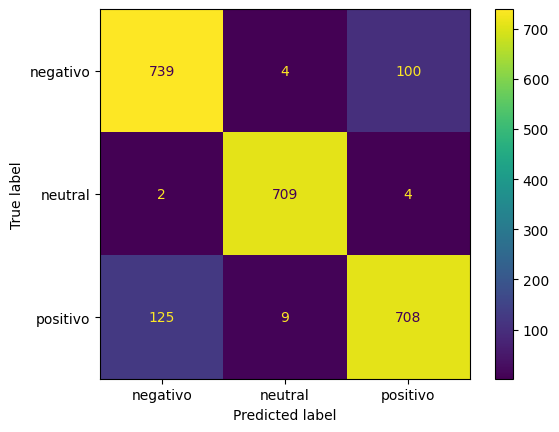

In [76]:
from sklearn.model_selection import RandomizedSearchCV

# La grilla conjunta de los tres votantes tiene 120 000 combinaciones, así que se muestrean n_iter al azar.
# Se omiten log_alpha, que no es un parámetro de MultinomialNB, y gamma en el SVC lineal, donde no tiene efecto.
param_distributions_voting = {
    **{f"svc_sigmoid__{k}": v for k, v in param_grid_svc.items()},
    **{f"svc_linear__{k}": v for k, v in param_grid_lin_svc.items() if k != "gamma"},
    **{f"nb__{k}": v for k, v in param_grid_naive_bayes.items() if k != "log_alpha"},
}

voting_search = RandomizedSearchCV(
    voting_classifier,
    param_distributions=param_distributions_voting,
    n_iter=30,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
voting_search.fit(X_train_transformed, y_train)

print(f"Mejores parámetros: {voting_search.best_params_}")
print(f"Accuracy en validación cruzada: {voting_search.best_score_:.4f}")

y_pred_voting_search = voting_search.predict(X_test_transformed)
print(f"Accuracy en test: {accuracy_score(y_test, y_pred_voting_search):.4f}")
print(classification_report(y_test, y_pred_voting_search))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_voting_search)
plt.show()

c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrador\AppData\Local\Programs\Python\Python31

Accuracy Stacking Classifier: 0.8975
              precision    recall  f1-score   support

    negativo       0.85      0.88      0.86       843
     neutral       0.99      0.99      0.99       715
    positivo       0.87      0.84      0.86       842

    accuracy                           0.90      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.90      0.90      0.90      2400



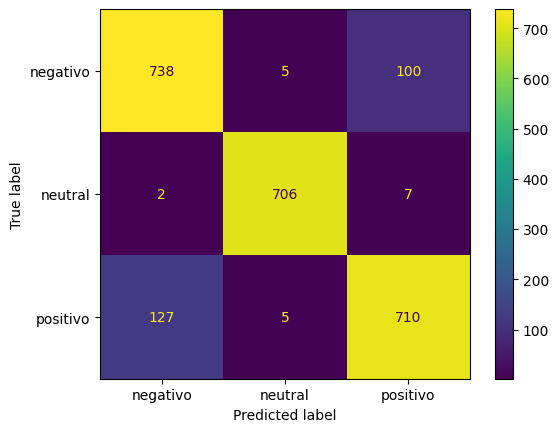

In [77]:
# El voto 'soft' requiere predict_proba, por lo que se crea un SVC nuevo con probability=True
from sklearn.ensemble import StackingClassifier
stacking_classifier = StackingClassifier(
    estimators=[
        ('svc_sigmoid', SVC(kernel="sigmoid", C=1.0, probability=True)),
        ('svc_linear', SVC(kernel="linear", C=1.0, probability=True)),
        ('nb', naive_bayes)
    ],
    final_estimator=LogisticRegression()
)
stacking_classifier.fit(X_train_transformed, y_train)
y_pred_stacking = stacking_classifier.predict(X_test_transformed)
accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
print(f"Accuracy Stacking Classifier: {accuracy_stacking}")
print(classification_report(y_test, y_pred_stacking))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_stacking)
plt.show()

# Identifcar la última opinión

En la sección *Análisis de las oraciones* vimos que, en las reseñas mixtas, la última opinión coincide con la etiqueta en el 84.5 % de los casos. Por eso el preprocesador incluye un vectorizador dedicado a la última oración (`last_sentence`).

Sin embargo, al revisar los datos encontramos que muchas reseñas **terminan con una oración de relleno**, sin ninguna opinión: *"Lo dejo a tu criterio"*, *"La uso principalmente en las tardes"*, *"Sigo con dudas, la verdad"*. En esos casos, la columna `last_sentence` no aporta información sobre el sentimiento, justo en el lugar donde más importa.

**Hipótesis:** si en lugar de la última oración a secas extraemos la **última cláusula que contiene una opinión** (un aspecto del producto con inflexión positiva o negativa), el modelo recibe directamente la parte del texto que decide la etiqueta.

Para detectar las opiniones reutilizamos las herramientas que ya construimos en el análisis de oraciones:

- `SEPARADOR_CLAUSULAS` divide el texto en cláusulas, cortando por puntuación y por conectores como *pero*, *aunque* o *y*. Así, de *"la pantalla es mala pero la batería es buena"* se obtienen dos cláusulas.
- `PATRON_ASPECTO` detecta si la cláusula menciona un aspecto del producto.
- `polaridad_clausula` decide si la cláusula expresa una opinión positiva o negativa.

La nueva columna **se agrega** a las existentes (texto completo, última oración y oración posterior al contraste); no reemplaza ninguna. Como es una regla determinista que no se ajusta con los datos, no introduce *data leakage*.

In [80]:
COLUMN_LAST_OPINION = "last_opinion"


def extract_last_opinion(text):
    """Devuelve la última cláusula del texto que menciona un aspecto con inflexión
    (positiva o negativa), o una cadena vacía si no se detecta ninguna opinión."""
    partes = SEPARADOR_CLAUSULAS.split(quitar_tildes(text.lower()))
    ultima = ""
    # split con grupo de captura intercala cláusulas (índices pares) y separadores (impares)
    for i in range(0, len(partes), 2):
        clausula = partes[i].strip(" ,")
        if PATRON_ASPECTO.findall(clausula) and polaridad_clausula(clausula):
            ultima = clausula
    return ultima


def add_last_opinion(X):
    """Agrega la columna con la última cláusula con opinión, conservando las columnas originales."""
    return X.assign(**{COLUMN_LAST_OPINION: X[TEXT_COLUMN].apply(extract_last_opinion)})


ejemplo = (
    "Lo compré hace un par de meses y lo tengo en la oficina. El sonido cumple de sobra "
    "para lo que lo uso. Eso sí, el diseño se dañó antes de lo que esperaba. Sigo con dudas, la verdad."
)
print("Última oración:            ", extract_last_sentences(ejemplo, 1))
print("Última cláusula con opinión:", extract_last_opinion(ejemplo))

Última oración:             Sigo con dudas, la verdad
Última cláusula con opinión: el diseno se dano antes de lo que esperaba


In [81]:
# Comparamos ambas columnas en algunas reseñas de entrenamiento
comparacion = add_last_opinion(add_last_sentences(X_train.head(8)))[
    [COLUMN_LAST_SENTENCE, COLUMN_LAST_OPINION]
].assign(label=y_train.head(8))
display(comparacion)

sin_opinion = (X_train[TEXT_COLUMN].apply(extract_last_opinion) == "").mean()
print(f"Reseñas de entrenamiento sin ninguna opinión detectada: {sin_opinion:.1%}")

,last_sentence,last_opinion,label
9455,"Por cierto, trae garantía de un año",,neutral
3459,"Con todo, el material se ve defectuoso la verdad","con todo, el material se ve defectuoso la verdad",negativo
11677,El epmaque no vale lo que cuesta,,negativo
9688,"Por cierto, la terminación vale totalmente la ...","por cierto, la terminacion vale totalmente la ...",positivo
7106,Trae garantia de un ano segun la caja,,neutral
5090,"Por cierto, la verdad, la atención al cliente ...","por cierto, la verdad, la atencion al cliente ...",positivo
4839,"Hay de todo, como se ve","la correa fue un error de compra, la uso con e...",negativo
5609,Lo he usado en la oficina estos días y la verd...,"ahora, por otro lado, me encanto el ensamblaje...",positivo


Reseñas de entrenamiento sin ninguna opinión detectada: 31.8%


### Integración al pipeline

Construimos un nuevo preprocesador a partir de `build_preprocessor`, con dos cambios:

1. Un paso inicial que crea la columna `last_opinion`. Va **antes** de `remove_first_sentence`, para que la extracción use la reseña completa.
2. Un cuarto vectorizador en el `ColumnTransformer`, con la misma configuración que los demás (tokenizador propio, stemming y n-gramas de 1 a 3).

Dejamos intacto el resto del pipeline y el mismo `VotingClassifier`, para que cualquier diferencia en el desempeño se deba únicamente a la nueva columna.

In [82]:
def build_preprocessor_opinion(vectorizer="tfidf", **kwargs):
    """Preprocesador base + columna con la última cláusula con opinión y su vectorizador."""
    preprocessor_opinion = build_preprocessor(vectorizer, **kwargs)
    preprocessor_opinion.steps.insert(
        0, ("last_opinion", FunctionTransformer(add_last_opinion))
    )
    preprocessor_opinion.named_steps["vectorizers"].transformers.append(
        (
            "last_opinion_vectorizer",
            vectorizer_function(vectorizer, **kwargs),
            COLUMN_LAST_OPINION,
        )
    )
    return preprocessor_opinion


# Mismo split que antes: el preprocesador se ajusta solo con train
preprocessor_opinion = build_preprocessor_opinion("tfidf")
X_train_opinion = preprocessor_opinion.fit_transform(X_train)
X_test_opinion = preprocessor_opinion.transform(X_test)

print(f"X - Train: {X_train_opinion.shape} | Test: {X_test_opinion.shape}")
print(
    "Vocabulario (last_opinion_vectorizer):",
    len(preprocessor_opinion.named_steps["vectorizers"].named_transformers_["last_opinion_vectorizer"].vocabulary_),
)

X - Train: (9600, 226130) | Test: (2400, 226130)
Vocabulario (last_opinion_vectorizer): 26486


c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Accuracy Voting (base):                 0.8992
Accuracy Voting (+ última opinión):     0.9021
Diferencia:                             +0.0029
              precision    recall  f1-score   support

    negativo       0.85      0.87      0.86       843
     neutral       1.00      1.00      1.00       715
    positivo       0.87      0.85      0.86       842

    accuracy                           0.90      2400
   macro avg       0.91      0.91      0.91      2400
weighted avg       0.90      0.90      0.90      2400



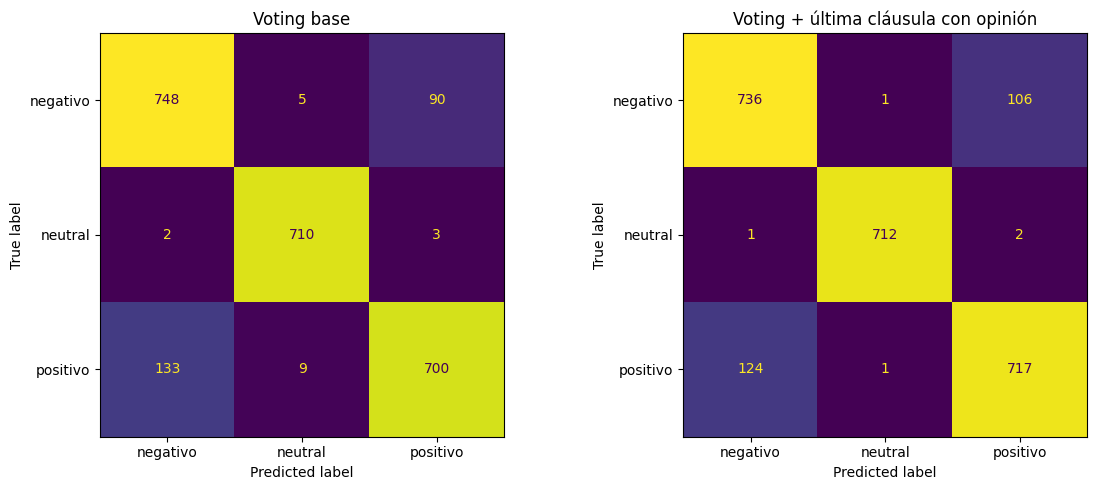

In [83]:
from sklearn.base import clone

# Mismo VotingClassifier de la sección anterior; fijamos random_state en las SVC para que el resultado sea replicable
voting_classifier_opinion = VotingClassifier(
    estimators=[
        ("svc_sigmoid", SVC(kernel="sigmoid", C=1.0, probability=True, random_state=42)),
        ("svc_linear", SVC(kernel="linear", C=1.0, probability=True, random_state=42)),
        ("nb", clone(naive_bayes)),
    ],
    voting="soft",
)
voting_classifier_opinion.fit(X_train_opinion, y_train)
y_pred_voting_opinion = voting_classifier_opinion.predict(X_test_opinion)
accuracy_voting_opinion = accuracy_score(y_test, y_pred_voting_opinion)

print(f"Accuracy Voting (base):                 {accuracy_voting:.4f}")
print(f"Accuracy Voting (+ última opinión):     {accuracy_voting_opinion:.4f}")
print(f"Diferencia:                             {accuracy_voting_opinion - accuracy_voting:+.4f}")
print(classification_report(y_test, y_pred_voting_opinion))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_voting, ax=axes[0], colorbar=False)
axes[0].set_title("Voting base")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_voting_opinion, ax=axes[1], colorbar=False)
axes[1].set_title("Voting + última cláusula con opinión")
plt.tight_layout()
plt.show()

### Resultados de la iteración

| Modelo | Accuracy (test) |
|---|---|
| Voting base | 0.8992 |
| Voting + última cláusula con opinión | 0.9021 |

La nueva columna mejora el accuracy en aproximadamente 0.03 puntos. Las matrices de confusión muestran de dónde viene la mejora.

Usamos este modelo para la siguiente submission.

## Creación de la submission


In [87]:
def create_submission_file(
    eval_file, model, transform=preprocessor_opinion.transform, filename="submission_8.csv"
):
    """Predice eval_file con el modelo y guarda la submission. transform convierte las reseñas en las
    features con las que se entrenó el modelo (por defecto, el preprocesador TF-IDF)."""
    eval_file = pd.read_csv(eval_file)
    submission = pd.DataFrame(
        {"id": eval_file["id"], "answer": model.predict(transform(eval_file))}
    )
    submission.to_csv(filename, index=False)


create_submission_file(
    "data/eval.csv",
    voting_classifier_opinion,
    transform=preprocessor_opinion.transform,
    filename="submission_8.csv",
)